In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Context

In [17]:
titanic_data = pd.read_csv('tested.csv', index_col='PassengerId')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Data quality assessment

In [18]:
print(f'Shape: {titanic_data.shape}')

Shape: (418, 11)


In [19]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Name      418 non-null    object 
 3   Sex       418 non-null    object 
 4   Age       332 non-null    float64
 5   SibSp     418 non-null    int64  
 6   Parch     418 non-null    int64  
 7   Ticket    418 non-null    object 
 8   Fare      417 non-null    float64
 9   Cabin     91 non-null     object 
 10  Embarked  418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 39.2+ KB


In [20]:
duplicate_rows = titanic_data.loc[titanic_data.duplicated().values]
duplicate_rows_count = duplicate_rows.shape[0]
print(f'Duplicate rows count: {duplicate_rows_count}')

Duplicate rows count: 0


In [21]:
survived_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Survived)].Survived.shape[0] / titanic_data.Survived.shape[0] * 100, 2 )
pclass_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Survived)].Pclass.shape[0] / titanic_data.Pclass.shape[0] * 100, 2)
name_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Name)].Name.shape[0] / titanic_data.Name.shape[0] * 100, 2)
sex_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Sex)].Sex.shape[0] / titanic_data.Sex.shape[0] * 100, 2)
age_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Age)].Age.shape[0] / titanic_data.Age.shape[0] * 100, 2)
sibsp_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.SibSp)].SibSp.shape[0] / titanic_data.SibSp.shape[0] * 100, 2)
parch_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Parch)].Parch.shape[0] / titanic_data.Parch.shape[0] * 100, 2)
ticket_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Ticket)].Ticket.shape[0] / titanic_data.Ticket.shape[0] * 100, 2)
fare_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Fare)].Fare.shape[0] / titanic_data.Fare.shape[0] * 100, 2)
cabin_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Cabin)].Cabin.shape[0] / titanic_data.Cabin.shape[0] * 100, 2)
embarked_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Embarked)].Embarked.shape[0] / titanic_data.Embarked.shape[0] * 100, 2)

column_names = titanic_data.columns.tolist()
notnull_percent = pd.DataFrame({'not-null, %': [survived_not0_percent, pclass_not0_percent, name_not0_percent, sex_not0_percent, age_not0_percent, sibsp_not0_percent, 
                                                parch_not0_percent, ticket_not0_percent, fare_not0_percent, cabin_not0_percent, embarked_not0_percent]}, index=[column_names])

notnull_percent

,"not-null, %"
Survived,100.00
Pclass,100.00
Name,100.00
Sex,100.00
Age,79.43
SibSp,100.00
Parch,100.00
Ticket,100.00
Fare,99.76
Cabin,21.77


# Data exploration

In [22]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


36.36% of passangers survived


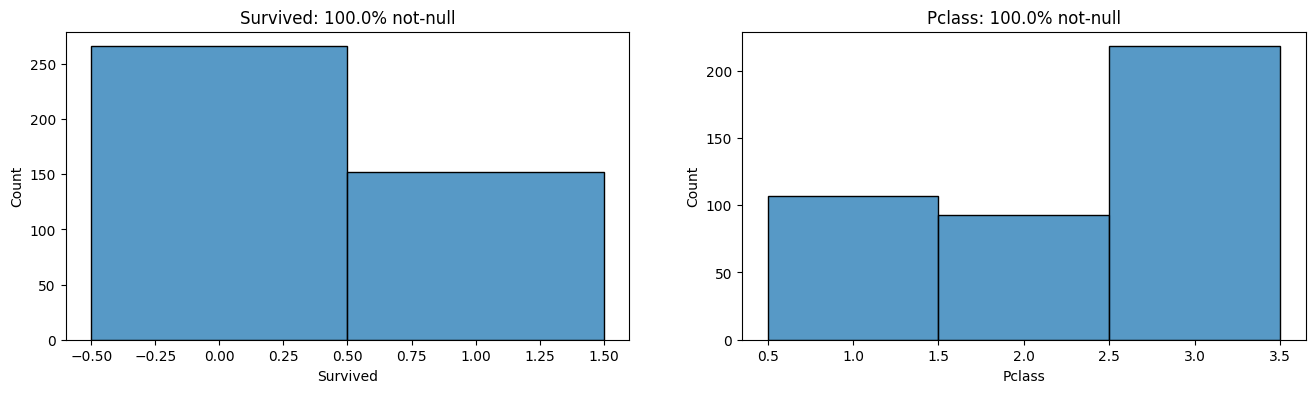

In [23]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(data = titanic_data, x = 'Survived', discrete=True, ax = axes[0])
axes[0].set_title(f'Survived: {survived_not0_percent}% not-null')

sns.histplot(data = titanic_data, x = 'Pclass', discrete=True, ax = axes[1])
axes[1].set_title(f'Pclass: {pclass_not0_percent}% not-null')

survived_percent = ((titanic_data.Survived[titanic_data['Survived'] == 1].count()) / (titanic_data.Survived.count()) * 100).round(2)
print(f'{survived_percent}% of passangers survived')

Text(0.5, 1.0, 'Sex: 100.0% not-null')

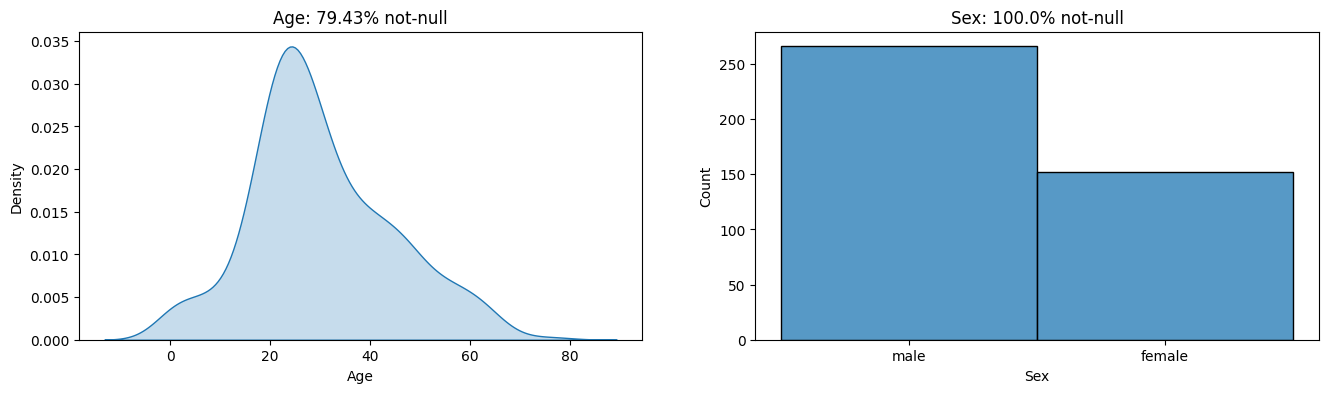

In [24]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.kdeplot(data = titanic_data['Age'], fill = True, ax = axes[0])
axes[0].set_title(f'Age: {age_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Sex', discrete=True, ax = axes[1])
axes[1].set_title(f'Sex: {sex_not0_percent}% not-null')

77.51% of passangers fly without any Parents/Children


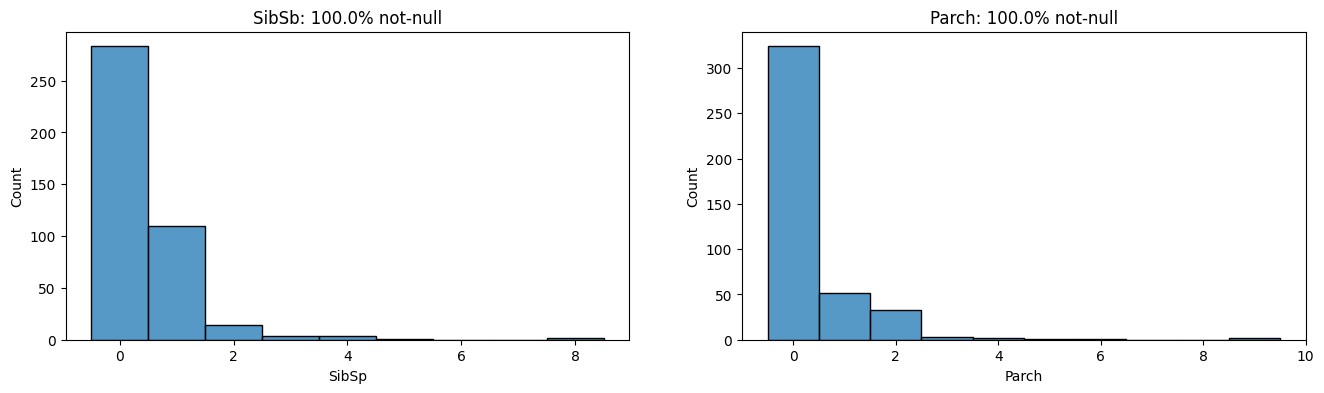

In [25]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(titanic_data, x ='SibSp', discrete=True, ax = axes[0])
axes[0].set_title(f'SibSb: {sibsp_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Parch', discrete=True, ax = axes[1])
axes[1].set_title(f'Parch: {parch_not0_percent}% not-null')

children_parents_percent = ((titanic_data.Parch[titanic_data['Parch'] == 0].count()) / (titanic_data.Parch.count()) * 100).round(2)
print(f'{children_parents_percent}% of passangers fly without any Parents/Children')


Percent of `S` Embarked : 64.59%


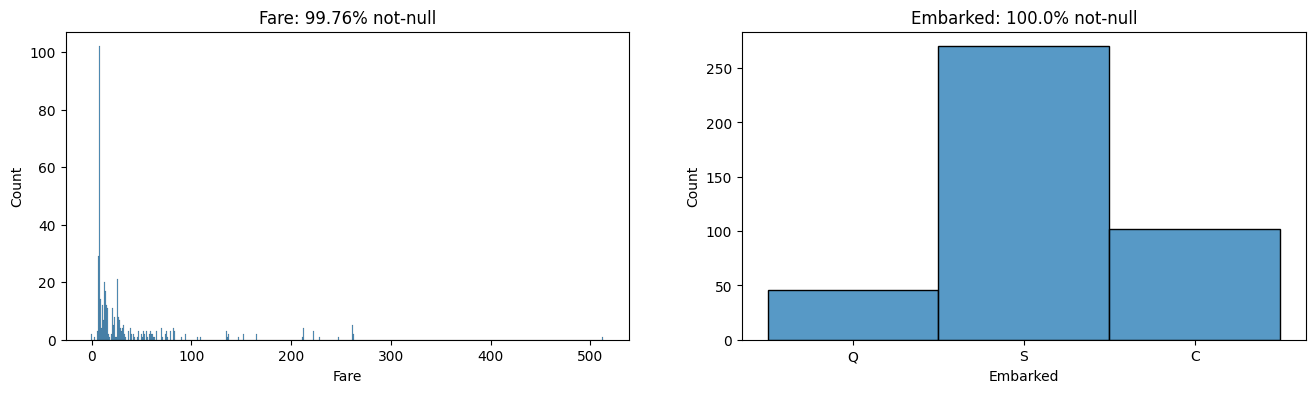

In [26]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(titanic_data, x ='Fare', discrete=True, ax = axes[0])
axes[0].set_title(f'Fare: {fare_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Embarked', discrete=True, ax = axes[1])
axes[1].set_title(f'Embarked: {embarked_not0_percent}% not-null')

embarked_percent = ((titanic_data.Embarked[titanic_data['Embarked'] == 'S'].count()) / (titanic_data.Parch.count()) * 100).round(2)
print(f'Percent of `S` Embarked : {embarked_percent}%')

In [27]:
titanic_data['LastName'] = titanic_data.Name.map(lambda p: p.split(',')[0])
titanic_data['FirstName'] = titanic_data.Name.map(lambda p: p.split('.')[1].split()[0])
titanic_data.Name.describe()

count                          418
unique                         418
top       Peter, Master. Michael J
freq                             1
Name: Name, dtype: object

Text(0, 0.5, 'First Name')

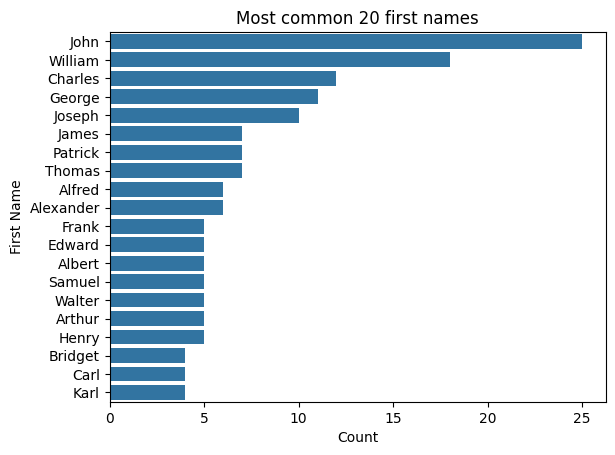

In [28]:
top_names = titanic_data.groupby('FirstName').FirstName.count().sort_values(ascending = False)

sns.barplot(y=top_names.iloc[0:20].index, x = top_names.iloc[0:20].values)
plt.title('Most common 20 first names') 
plt.xlabel('Count')
plt.ylabel('First Name')

Text(0, 0.5, 'Last Name')

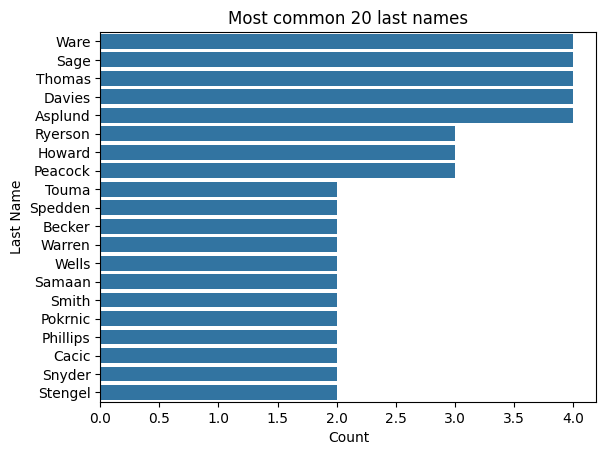

In [29]:
top_names = titanic_data.groupby('LastName').LastName.count().sort_values(ascending = False)

sns.barplot(y=top_names.iloc[0:20].index, x = top_names.iloc[0:20].values)
plt.title('Most common 20 last names') 
plt.xlabel('Count')
plt.ylabel('Last Name')

In [30]:
titanic_data.Ticket.describe()

count          418
unique         363
top       PC 17608
freq             5
Name: Ticket, dtype: object

Text(0, 0.5, 'Ticket')

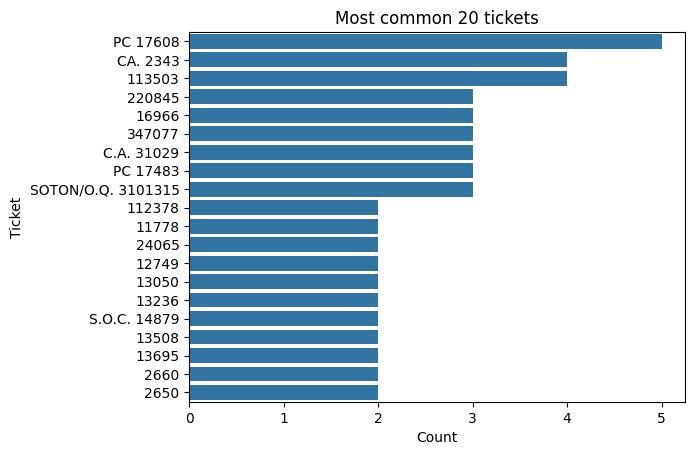

In [31]:
top_ticket_names = titanic_data.groupby('Ticket').Ticket.count().sort_values(ascending = False)

sns.barplot(y=top_ticket_names.iloc[0:20].index, x = top_ticket_names.iloc[0:20].values)
plt.title('Most common 20 tickets') 
plt.xlabel('Count')
plt.ylabel('Ticket')

In [32]:
titanic_data.Cabin.describe()

count                  91
unique                 76
top       B57 B59 B63 B66
freq                    3
Name: Cabin, dtype: object

Text(0, 0.5, 'Cabins')

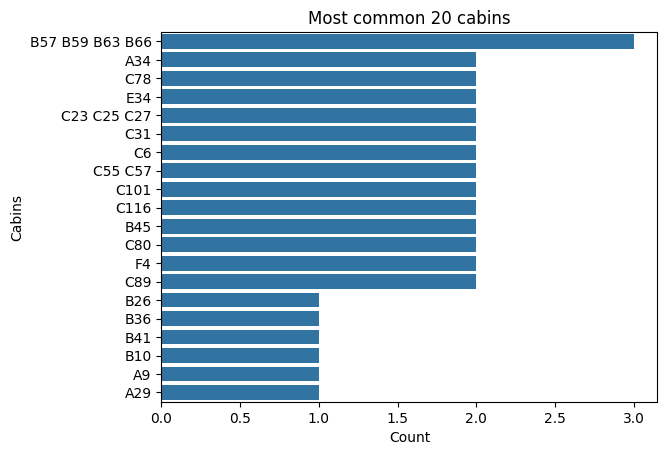

In [33]:
top_cabin_names = titanic_data.groupby('Cabin').Cabin.count().sort_values(ascending = False)

sns.barplot(y=top_cabin_names.iloc[0:20].index, x = top_cabin_names.iloc[0:20].values)
plt.title('Most common 20 cabins') 
plt.xlabel('Count')
plt.ylabel('Cabins')

Text(0.5, 1.0, 'Fare / Age relationship')

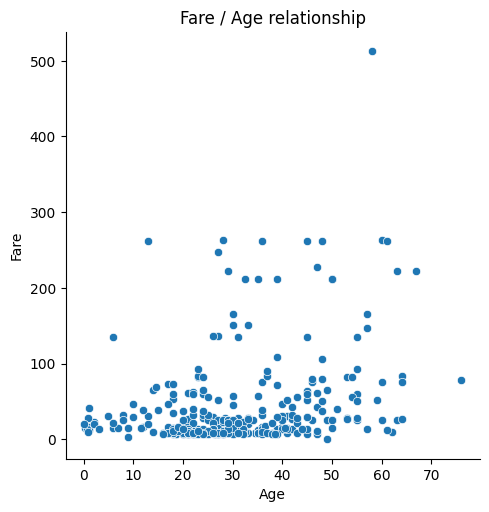

In [34]:
sns.relplot(data=titanic_data, x="Age", y="Fare")
plt.title('Fare / Age relationship')

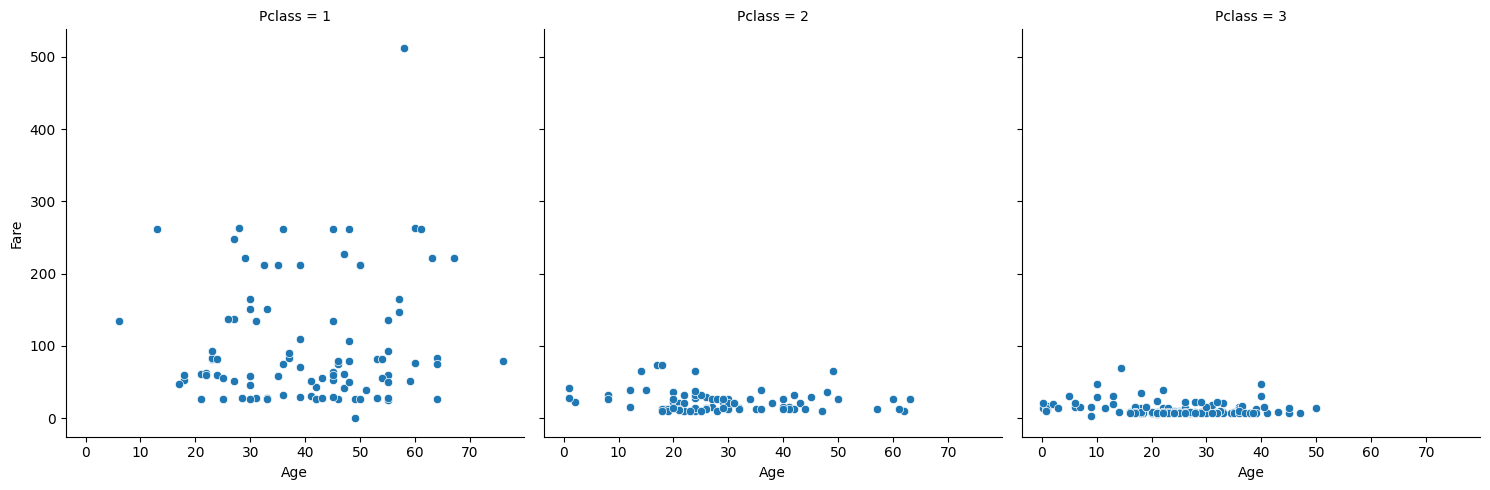

In [35]:
sns.relplot(data=titanic_data, x="Age", y="Fare", col='Pclass')

Text(0.5, 0, 'Passenger class')

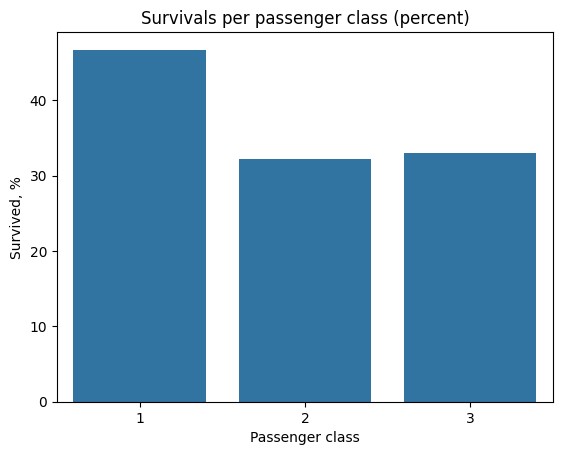

In [36]:
pclass_total_stats = titanic_data.groupby(['Pclass']).Name.count()
pclass_stats = pd.DataFrame(data = pclass_total_stats)
pclass_stats = pclass_stats.rename(columns = {'Name':'Total'})
pclass_stats['Survived'] = titanic_data.loc[titanic_data.Survived == True].groupby(['Pclass']).Name.count()
pclass_stats['Survived_percent'] = round(pclass_stats.Survived / pclass_stats.Total * 100, 2)

sns.barplot(x = pclass_stats.index, y = pclass_stats.Survived_percent)
plt.title('Survivals per passenger class (percent)')
plt.ylabel('Survived, %')
plt.xlabel('Passenger class')

(0.0, 150.0)

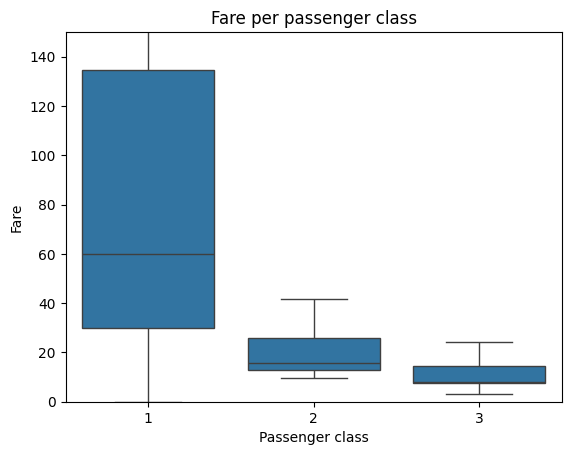

In [37]:
sns.boxplot(data=titanic_data, x="Pclass", y="Fare", showfliers = False)
plt.title('Fare per passenger class')
plt.ylabel('Fare')
plt.xlabel('Passenger class')
plt.ylim(0,150)

(0.0, 60.0)

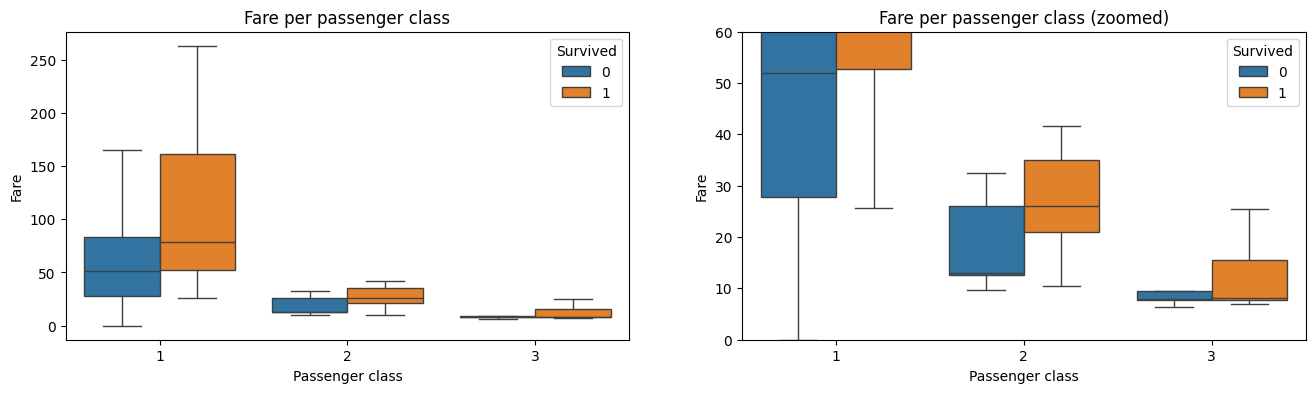

In [38]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Pclass", y="Fare", hue="Survived", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per passenger class')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Passenger class')

sns.boxplot(data=titanic_data, x="Pclass", y="Fare", hue="Survived", showfliers = False, ax = axes[1])
axes[1].set_title('Fare per passenger class (zoomed)')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Passenger class')
axes[1].set_ylim(0, 60)

Text(0.5, 0, 'Passenger class')

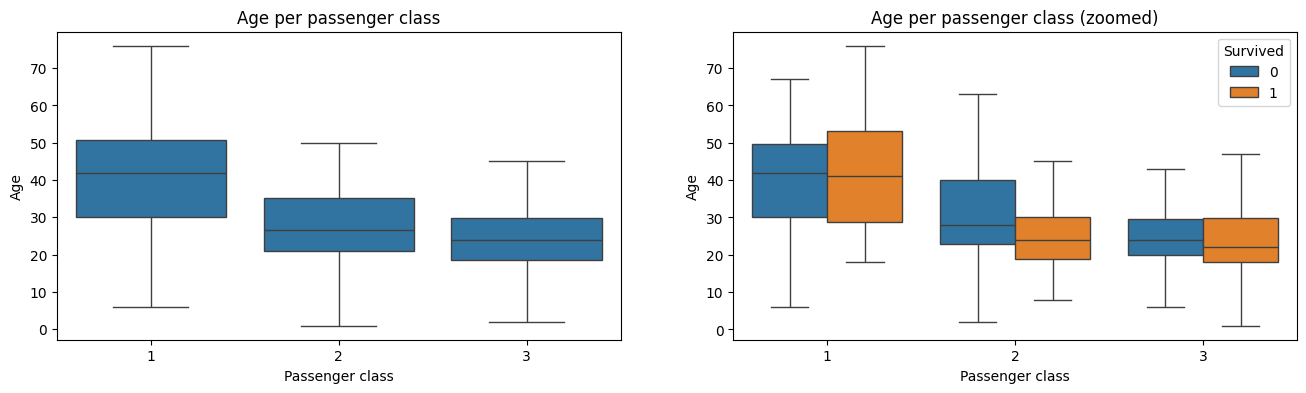

In [39]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Pclass", y="Age", showfliers = False, ax = axes[0])
axes[0].set_title('Age per passenger class')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('Passenger class')

sns.boxplot(data=titanic_data, x="Pclass", y="Age", hue='Survived', showfliers = False, ax = axes[1])
axes[1].set_title('Age per passenger class (zoomed)')
axes[1].set_ylabel('Age')
axes[1].set_xlabel('Passenger class')

In [40]:
def child_adult(row): 
    if (row.Age >= 18):
        row.ChildAdult = 'Adult'
    elif (row.Age < 18 and row.Age >= 0):
        row.ChildAdult = 'Child'
    else:
        row.ChildAdult = np.nan 
    return row

titanic_data['ChildAdult'] = titanic_data['Sex']
titanic_data = titanic_data.apply(child_adult, axis='columns')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,FirstName,ChildAdult
PassengerId,,,,,,,,,,,,,,
892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Kelly,James,Adult
893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Wilkes,James,Adult
894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Myles,Thomas,Adult
895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Wirz,Albert,Adult
896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Hirvonen,Alexander,Adult


Percent of children : 12.35%


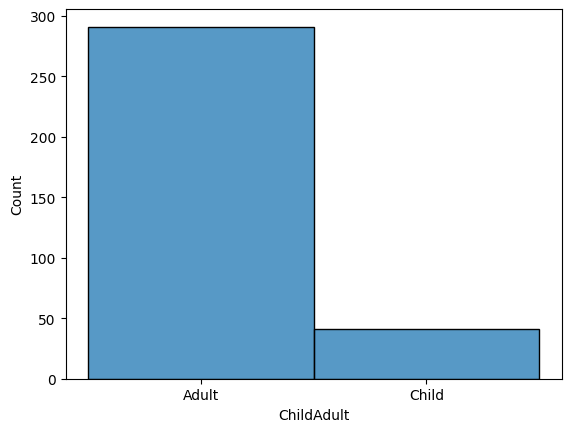

In [41]:
sns.histplot(titanic_data['ChildAdult'])

child_percent = ((titanic_data.ChildAdult[titanic_data['ChildAdult'] == 'Child'].count()) / (titanic_data.ChildAdult.count()) * 100).round(2)
print(f'Percent of children : {child_percent}%')

Text(0.5, 0, 'Age')

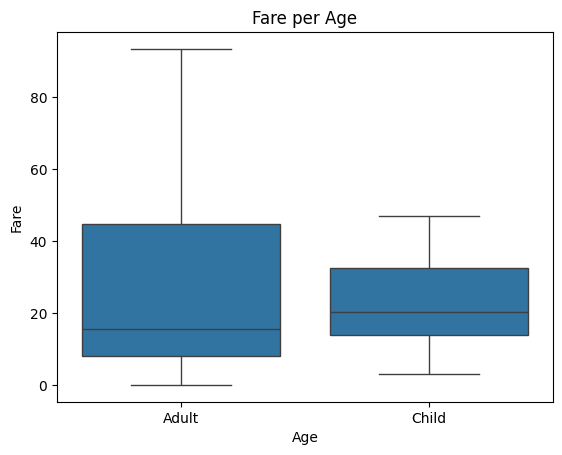

In [42]:
sns.boxplot(data=titanic_data, x="ChildAdult", y="Fare", showfliers = False)
plt.title('Fare per Age')
plt.ylabel('Fare')
plt.xlabel('Age')

Text(0.5, 0, 'Sex')

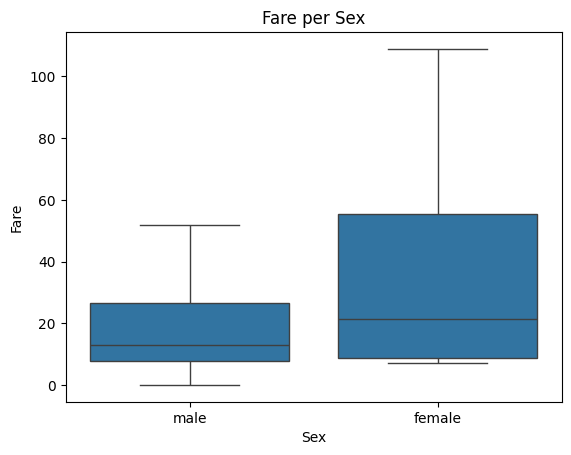

In [43]:
sns.boxplot(data=titanic_data, x="Sex", y="Fare", showfliers = False)
plt.title('Fare per Sex')
plt.ylabel('Fare')
plt.xlabel('Sex')

Text(0.5, 0, 'Number of Parents/Children')

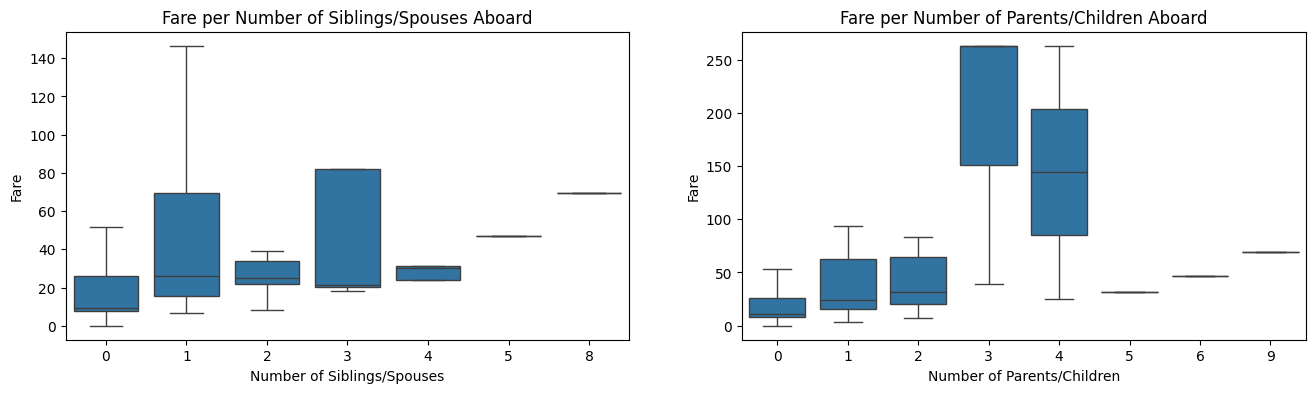

In [44]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="SibSp", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per Number of Siblings/Spouses Aboard')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Number of Siblings/Spouses')

sns.boxplot(data=titanic_data, x="Parch", y="Fare", showfliers = False, ax = axes[1])
axes[1].set_title('Fare per Number of Parents/Children Aboard')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Number of Parents/Children')

Text(0, 0.5, 'Name')

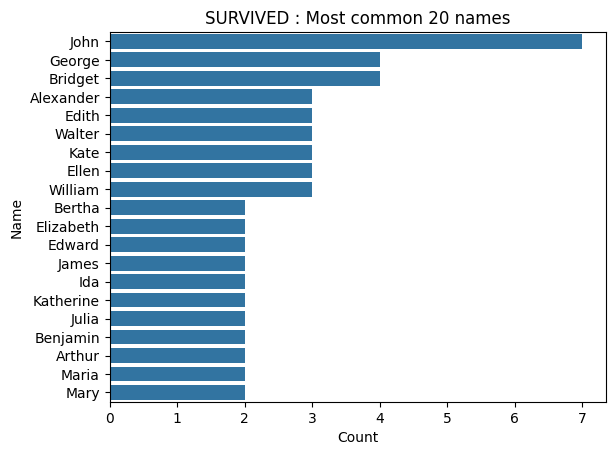

In [50]:
top_survived_names = titanic_data.loc[titanic_data.Survived == True].groupby('FirstName').Name.count().sort_values(ascending = False)

sns.barplot(y=top_survived_names.iloc[0:20].index, x = top_survived_names.iloc[0:20].values)
plt.title(f"SURVIVED : Most common 20 names")
plt.xlabel(f"Count")
plt.ylabel(f"Name")

Text(0, 0.5, 'Name')

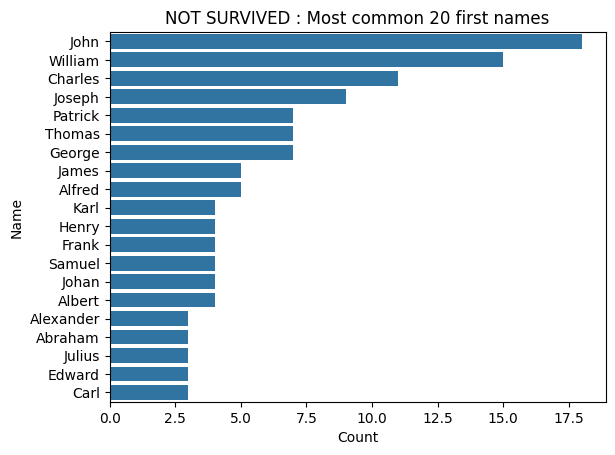

In [52]:
top_not_survived_names = titanic_data.loc[titanic_data.Survived == False].groupby('FirstName').Name.count().sort_values(ascending = False)

sns.barplot(y=top_not_survived_names.iloc[0:20].index, x = top_not_survived_names.iloc[0:20].values)
plt.title(f"NOT SURVIVED : Most common 20 first names")
plt.xlabel(f"Count")
plt.ylabel(f"Name")

Text(0, 0.5, 'Last Name')

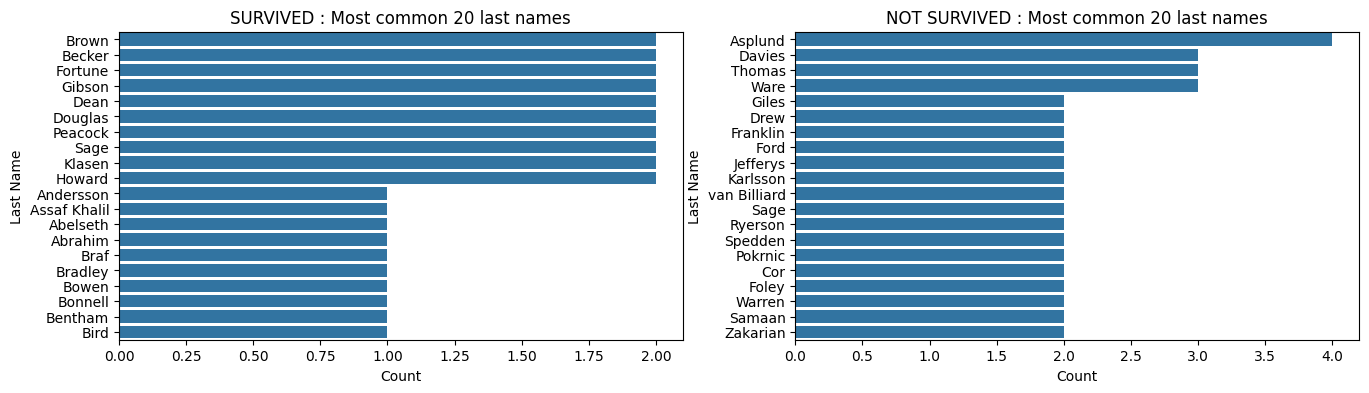

In [53]:
top_survived_last_names = titanic_data.loc[titanic_data.Survived == True].groupby('LastName').Name.count().sort_values(ascending = False)
top_not_survived_last_names = titanic_data.loc[titanic_data.Survived == False].groupby('LastName').Name.count().sort_values(ascending = False)
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.barplot(y=top_survived_last_names.iloc[0:20].index, x = top_survived_last_names.iloc[0:20].values , ax = axes[0])
axes[0].set_title(f"SURVIVED : Most common 20 last names")
axes[0].set_xlabel(f"Count")
axes[0].set_ylabel(f"Last Name")

sns.barplot(y=top_not_survived_last_names.iloc[0:20].index, x = top_not_survived_last_names.iloc[0:20].values , ax = axes[1])
axes[1].set_title(f"NOT SURVIVED : Most common 20 last names")
axes[1].set_xlabel(f"Count")
axes[1].set_ylabel(f"Last Name")

(0.0, 120.0)

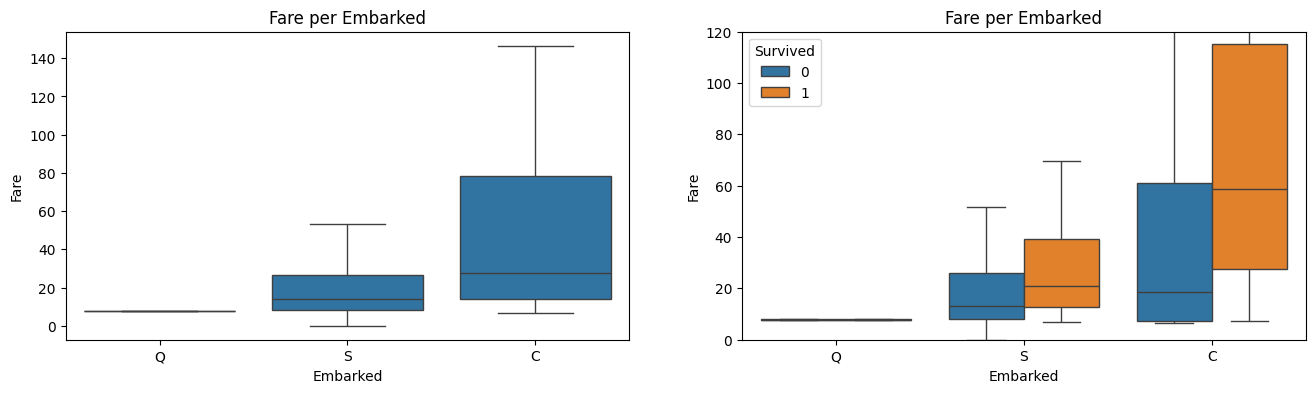

In [58]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Embarked", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per Embarked')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Embarked')

sns.boxplot(data=titanic_data, x="Embarked", y="Fare", hue='Survived', showfliers = False)
axes[1].set_title('Fare per Embarked')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Embarked')
axes[1].set_ylim(0,120)

Text(0.5, 0, 'Embarked')

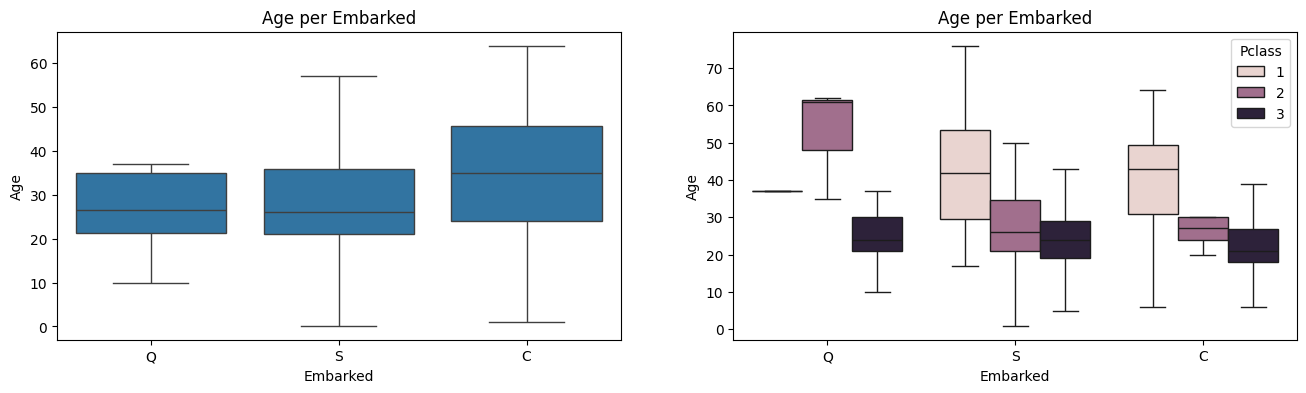

In [59]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Embarked", y="Age", showfliers = False, ax = axes[0])
axes[0].set_title('Age per Embarked')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('Embarked')

sns.boxplot(data=titanic_data, x="Embarked", y="Age", hue='Pclass', showfliers = False)
axes[1].set_title('Age per Embarked')
axes[1].set_ylabel('Age')
axes[1].set_xlabel('Embarked')

# Summary

36.36% of passangers survived.
To survive it is better to fly first class.
The higher the passenger class, the higher the ticket fare.
The older the passenger, the higher the passenger class.
The passenger's age does not affect the ticket price.
The ticket price for female was higher than for male.
Passengers with 3 Sibling/Spouse on board pay the most per flight.
Passengers without Siblings/Spouses on board pay the least per flight.
Passengers with 3 Parent/Children on board pay the most per flight.
Passengers without Parent/Children on board pay the least per flight.
The cheapest Embarked point is Q (Queenstown).
Most passengers(64.59%) choose Embarked point S (Southampton).